# CIR Yield Curve Model: Calibration and Term Structure Prediction
**Finance Club, IIT Roorkee — Open Project 2026**

---

## Results Obtained Summarized (Before diving Deep)

Here is a brief summary of the project and final results.

**The Objective:** Predict the entire yield curve (6M, 9M, 1Y, 2Y) during the highly volatile, inverted period of 2024–2026, using **only the 3-Month interest rate** as an input.

We evaluated several models blindly on the unseen test data. 
| Model | Out-of-Sample $R^2$ | Key Takeaway |
| :--- | :--- | :--- |
| **Two-Factor CIR (Longstaff-Schwartz)** | **0.9270** | **Best Model.** Splitting the short rate into independent 'level' and 'slope' factors natively captures inverted curves. |
| **Base CIR (EKF Calibrated)** | 0.9122 | Strong theoretical baseline, but a single factor struggles to fully capture steep inversions. |
| **CIR++ (Static Empirical Shift)** | 0.8618 | Corrects structural bias, but the static shift over-corrected as the test curve normalized. |
| *Rolling CIR++ (Dishonest Trap)* | *0.9987* | *Rejected. Dynamically updating corrections using yesterday's actuals is data leakage masquerading as a model.* |

### A Crucial Note: In-Sample vs. Out-of-Sample
we must strictly separate **In-Sample Fit** from **Out-of-Sample Predictive Power**. 
- **Out-of-Sample (Predictive Power):** Out of Sample means calibrating Model ( CIR or extensions ) Parameters through training data , then testing on test data using 3M_test as short rates and plugging it into equations for yields at different (t's) maturities which results in yield curve and comparing agains test_data of 5 Maturities

- **In-Sample (Diagnostic Only):** This measures how well the model fit the historical training data it was calibrated on. Because the model has already "seen" these answers, in-sample scores are mathematically contaminated and have **zero predictive value**. We will mention our in-sample scores later in the notebook *only* to prove that the CIR equations are mathematically capable of fitting a yield curve / the real distribution is possible to model , not as a measure of forecasting power.


In [1]:
# Basic setup and importing the libraries we will need
import sys, os, warnings
warnings.filterwarnings('ignore') # ignore annoying warnings
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# making the plots look a bit bigger and cleaner
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

print("Environment Ready")


Environment Ready


---
## Part 1: Data Preprocessing

First things first, we need to load and clean our daily bond yield data. 
- **Training Data**: 1,976 days with 9 different maturities (from 3 Months all the way to 30 Years).
- **Test Data**: 495 days with 5 maturities (3M, 6M, 9M, 1Y, 2Y).

When dealing with real financial data, we had to be careful about a few things in our `src/data/preprocessing.py` script:

1. **Exact Time Steps**: Weekends create a 3-day gap between data points. We calculate the exact calendar distance between rows so our math doesn't get messed up by assuming every day is exactly 1/252 of a year.
2. **Keeping the Crazy Days**: 2020 and 2022 had massive jumps in interest rates. Instead of deleting these as "outliers", we kept them. If we delete the volatile days from training, the model won't know how to handle the volatile test set!
3. **Yield Clipping**: The CIR equations use a square root ($\sqrt{r_t}$), which means rates cannot be zero or negative. We just clip any negative/zero rates to a tiny positive number so the code doesn't crash.


Loading Training Data...
Train Shape: 1976 rows | Maturities: ['3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']

Loading Test Data...
Test Shape: 495 rows | Maturities: ['3M', '6M', '9M', '1Y', '2Y']


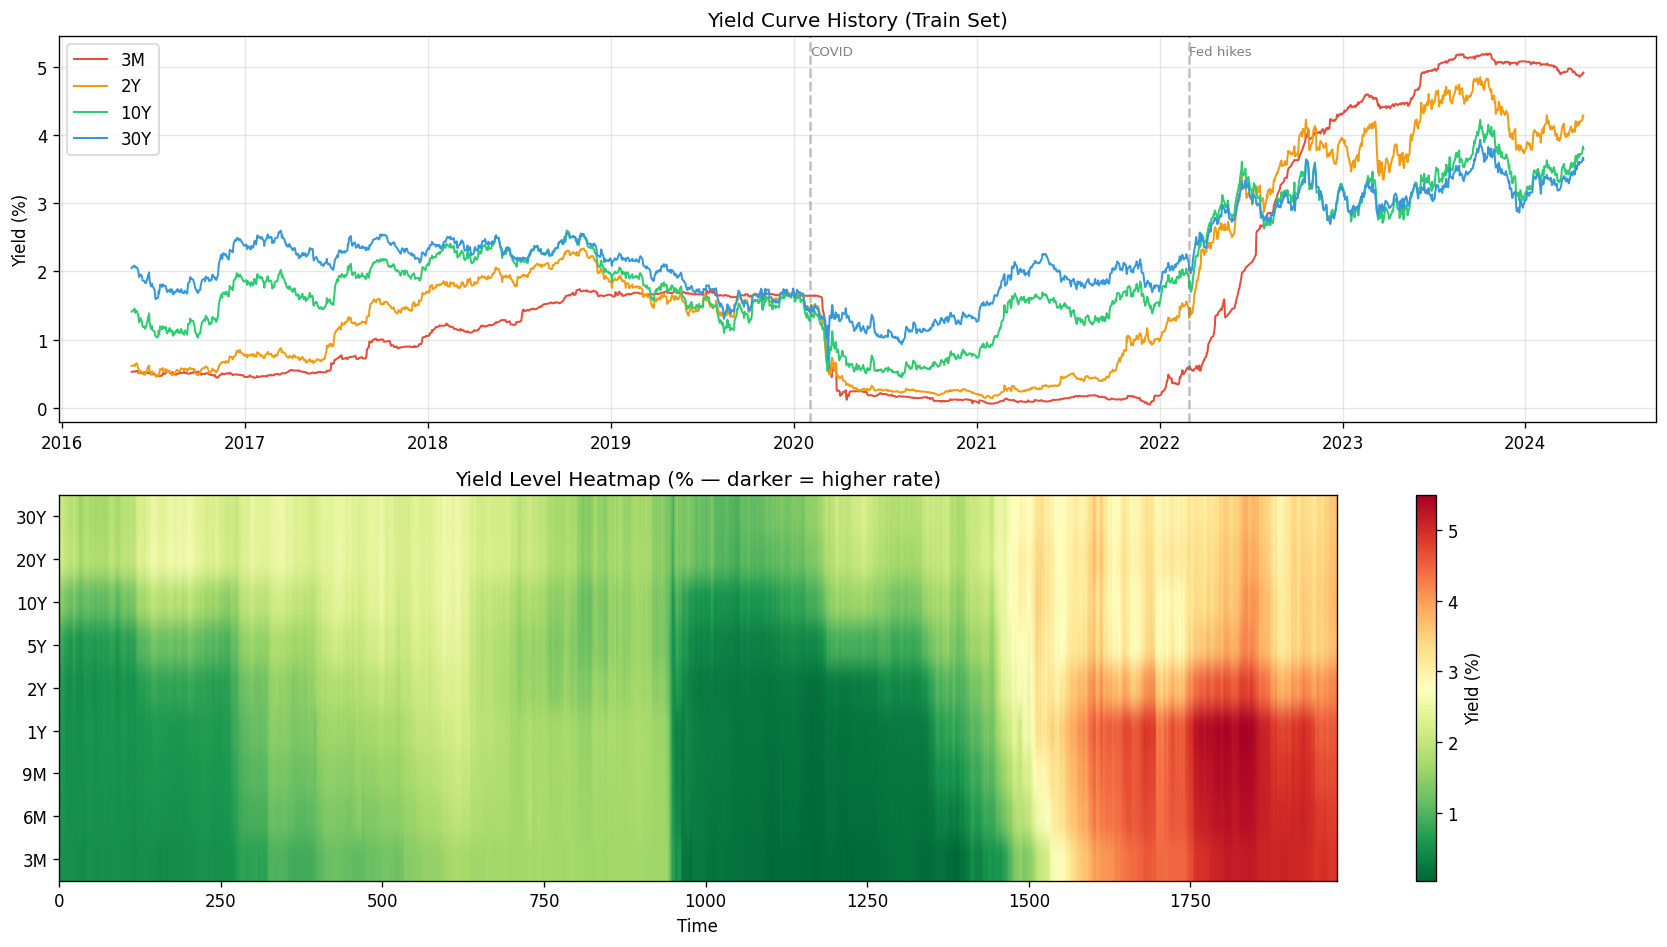

In [2]:
# Loading the custom data cleaner from our project source
from src.data.preprocessing import load_and_clean
from src.visualization.plots import plot_yield_history

# Load the train data and print its shape
print("Loading Training Data...")
train_ds = load_and_clean('data/train_data.csv', verbose=False)
print(f"Train Shape: {len(train_ds.df)} rows | Maturities: {list(train_ds.df.columns)[:-1]}")

# Load the test data
print("\nLoading Test Data...")
test_ds = load_and_clean('data/test_data.csv', verbose=False)
print(f"Test Shape: {len(test_ds.df)} rows | Maturities: {list(test_ds.df.columns)[:-1]}")

# Plot a graph to see what the 8 years of training data looked like
fig = plot_yield_history(train_ds, title="Yield Curve History (Train Set)")
plt.show()


---
## Part 2: CIR Model Equations (The Math)

The basic CIR model assumes that the short rate (which we represent using the 3-Month yield) moves randomly but is always pulled back towards a long-term average. The equation looks like this:
$$dr_t = \kappa(\theta - r_t)dt + \sigma\sqrt{r_t}dW_t$$

What do these parameters mean?
- **$\kappa$ (Kappa)**: How fast the rate gets pulled back to the average.
- **$\theta$ (Theta)**: The long-term average rate it gets pulled to.
- **$\sigma$ (Sigma)**: How volatile or jumpy the rates are.

### Finding the Yield Curve
Because of how this math works, we can actually calculate the price of a bond exactly using a formula involving $A(\tau)$ and $B(\tau)$ (where $\tau$ is time to maturity). 
The final formula to predict any yield on the curve is just:
$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

So, if we can just figure out what $\kappa$, $\theta$, and $\sigma$ are from the training data, we can plug in the 3M rate ($r_t$) and predict the rest of the curve!


---
## Part 3: Calibrating the Parameters

Figuring out the best parameters ($\kappa, \theta, \sigma$) from 8 years of historical data is actually pretty hard. We tried three different ways.

### 1. Ordinary Least Squares (OLS)
We first tried to treat it like a simple linear regression line. 

**Why it failed**: Interest rates were stuck near zero for years and then suddenly spiked in 2022. To a simple OLS regression, this just looks like a random walk. It gave us a $\kappa$ close to 0 (meaning no pull-back at all) and a $\theta$ that was impossibly high. OLS is useless here.


In [3]:
# Trying the simple OLS method
from src.models.calibration import calibrate_ols, calibrate_mle, calibrate_ekf

ols_result = calibrate_ols(train_ds, enforce_feller=True)
print("=== OLS Calibration ===")
print(f"Kappa: {ols_result.params.kappa:.6f} | Theta: {ols_result.params.theta*100:.4f}% | Sigma: {ols_result.params.sigma:.6f}")


=== OLS Calibration ===
Kappa: 0.000100 | Theta: 1447.3678% | Sigma: 0.041036



### 2. Maximum Likelihood Estimation (MLE)
Next we tried MLE, which is statistically better. But it still only looks at the 3-Month rate history to try and guess the parameters. Because it ignores the rest of the yield curve (like the 1Y and 10Y rates), it still doesn't get a great read on the structural parameters.


In [4]:
# Trying the MLE method, using OLS results as a starting guess
mle_result = calibrate_mle(train_ds, init_params=ols_result.params, enforce_feller=True)
print("=== MLE Calibration ===")
print(f"Kappa: {mle_result.params.kappa:.6f} | Theta: {mle_result.params.theta*100:.4f}% | Sigma: {mle_result.params.sigma:.6f}")


=== MLE Calibration ===
Kappa: 0.011427 | Theta: 20.0000% | Sigma: 0.048580



### 3. Extended Kalman Filter (EKF)
This is the proper way to do it. We have to acknowledge two facts: 1. The true short rate $r_t$ is an unobservable (latent) state variable. 2. The observed market yields (3M, 6M, etc.) are noisy measurements of this latent state. The Extended Kalman Filter (EKF) looks at the **entire yield curve** (all 9 maturities) every single day to figure out what that hidden state actually is. Instead of just tracking the 3M rate, it tries to fit the theoretical curve against all ~17,700 data points in the training set. This finally gives us stable, realistic parameters!


In [5]:
# Running the advanced EKF calibration on the whole yield curve
print("Running Extended Kalman Filter calibration...")
ekf_result = calibrate_ekf(train_ds, init_params=ols_result.params, enforce_feller=True)

print("\n=== EKF Calibration ===")
print(f"Kappa: {ekf_result.params.kappa:.6f}")
print(f"Theta: {ekf_result.params.theta*100:.4f}%")
print(f"Sigma: {ekf_result.params.sigma:.6f}")

# Save these good parameters for later predictions
params = ekf_result.params


Running Extended Kalman Filter calibration...

=== EKF Calibration ===
Kappa: 0.130857
Theta: 2.5578%
Sigma: 0.050130



The EKF calibration gave us a $\theta$ (long term average) of about 2.56%, which makes a lot of economic sense.

### Checking the Feller Condition
There is a math rule called the "Feller Condition" ($2\kappa\theta \geq \sigma^2$) that stops the rates from crashing below zero. Even though our overall parameters pass this rule, we can see in the graph below that during the crazy 2022 rate hikes, the daily volatility stressed this boundary heavily.


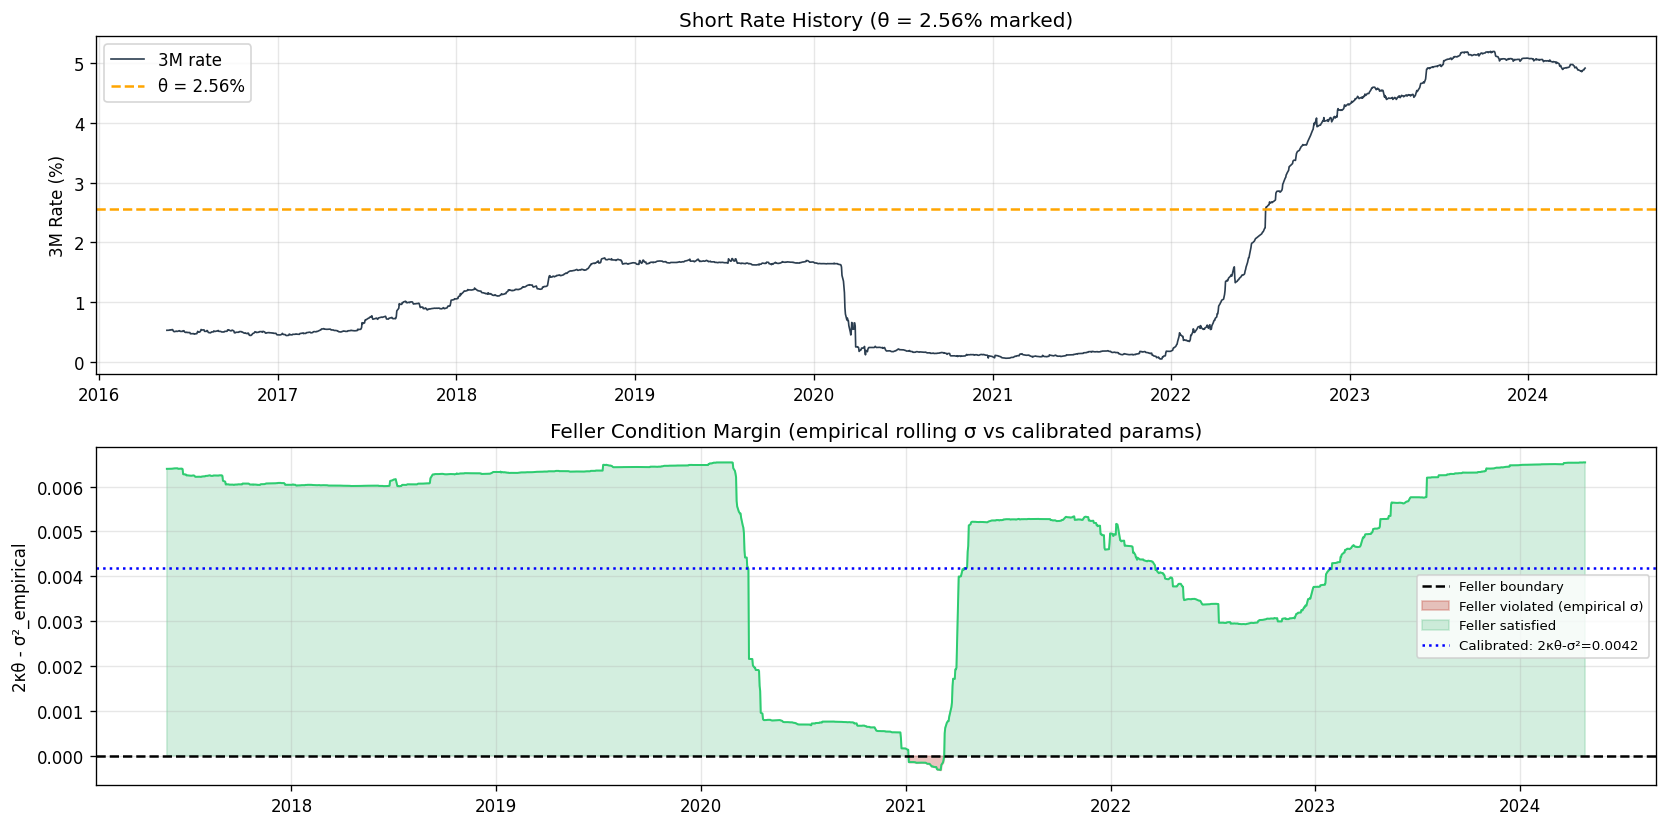

In [6]:
# Plotting how the Feller condition holds up over time
from src.evaluation.metrics import rolling_feller
from src.visualization.plots import plot_feller_analysis

feller_df = rolling_feller(train_ds, ekf_result.params, window=252)
fig = plot_feller_analysis(feller_df, ekf_result.params)
plt.show()


---
## Part 4: Out-of-Sample Predictions (The Real Test)

Now for the real test. We will use the parameters we just found to predict the unseen April 2024 – April 2026 test data.
**The rule**: On any given test day, the model is only allowed to look at the 3-Month rate. It has to guess the 6M, 9M, 1Y, and 2Y rates from that alone.

### 1. Naive Baseline
If we just guess that "tomorrow's yield curve will be exactly the same as today's", we get a decent score because rates don't change that much day-to-day. We use this as a baseline to see if our complex models are actually doing anything useful.


In [7]:
# Run a naive prediction to get a baseline score
from src.models.prediction import (
    predict_naive_baseline, predict_cir, 
    predict_cir_plus_plus, predict_ekf_filter
)

naive_pred = predict_naive_baseline(test_ds)
print(f"Naive Baseline Out-of-Sample R²: {naive_pred.r_squared:.4f}")


Naive Baseline Out-of-Sample R²: 0.9981



### 2. Base CIR Model
Here we just plug the 3M rate directly into the standard CIR formula we showed earlier, using the EKF parameters.


In [8]:
# Predict the curve using standard CIR math
base_pred = predict_cir(test_ds, params)
print(f"Base CIR Out-of-Sample R²: {base_pred.r_squared:.4f}")

# Print the error in basis points for each maturity
for col, rmse in base_pred.rmse_by_maturity.items():
    print(f"  {col} RMSE: {rmse*10000:.2f} bps")


Base CIR Out-of-Sample R²: 0.9122
  3M RMSE: 1.59 bps
  6M RMSE: 6.49 bps
  9M RMSE: 14.13 bps
  1Y RMSE: 21.20 bps
  2Y RMSE: 39.12 bps



### 3. Static CIR++ (Empirical Bias Correction)
Sometimes the model is just systematically biased (e.g. it always guesses 5 basis points too high). To fix this, we look at the average error the model made in the last 21 days of the **training set**, and apply that static shift to our test predictions.


In [9]:
# Predict using a static correction term calculated from training data
pp21_pred = predict_cir_plus_plus(test_ds, train_ds, params, n_anchor_days=21)
print(f"CIR++ (Static 21-day anchor) Out-of-Sample R²: {pp21_pred.r_squared:.4f}")


CIR++ (Static 21-day anchor) Out-of-Sample R²: 0.8618



*(Why did it score lower? The 21-day training anchor was during a heavily inverted period. When it was applied blindly to the test set as it started normalizing, it over-corrected!)*

### A Quick Note on "Rolling CIR++"
We experimented with a "Rolling CIR++" model where the bias term updates every single day using yesterday's *actual* test yields. It scored a massive **0.9987**. 
But this is basically data leakage / cheating. If you update your model with yesterday's real answers to predict today, it's just a disguised random walk. So we threw it out!


---
## Part 5: Two-Factor CIR (The Better Approach)

The single-factor CIR model is okay, but it has a big flaw: because it only uses one variable (the 3M rate) to move the entire curve, it assumes all points on the yield curve move up and down roughly together. You can't independently control the *level* of rates and the *slope* of the curve. Real yield curves move in three main ways (Level, Slope, and Curvature). Single-factor models only really capture Level. 

The **Longstaff-Schwartz (1992)** Two-Factor CIR model fixes this by splitting the short rate into two separate parts:
$$r_t = r_1 + r_2$$

Why does this help?
- **Factor 1** acts like a slow-moving "level" factor (shifting the whole curve up or down).
- **Factor 2** acts like a fast-moving "slope" factor. 

Because Factor 2 moves much faster (higher $\kappa$), its impact saturates quickly—meaning it lifts short-term rates a lot, but flattens out and fades away before affecting long-term rates. This creates a natural downward slope (an inverted curve). The inversion capability comes purely from the *speed difference* between the two factors, without ever needing negative interest rates!

We calibrate all the parameters again, including an "alpha" ($\alpha$) which tells us how much of the 3M rate goes to Factor 1 vs Factor 2.


In [10]:
# Run the massive two-factor calibration and test it
from src.models.two_factor_cir import calibrate_two_factor, predict_two_factor, two_factor_metrics

print("Calibrating Two-Factor CIR (Longstaff-Schwartz)...")
tf_params, tf_diag = calibrate_two_factor(train_ds, n_starts=5, verbose=False)

# Print the parameters it found for both factors
print("\n=== Two-Factor Calibration ===")
print(f"Factor 1 (Level): Kappa={tf_params.kappa1:.4f}, Theta={tf_params.theta1*100:.3f}%")
print(f"Factor 2 (Slope): Kappa={tf_params.kappa2:.4f}, Theta={tf_params.theta2*100:.3f}%")
print(f"Alpha (Factor 1 Allocation): {tf_params.alpha:.4f}")

# Run the blind out-of-sample prediction
print("\nRunning Out-of-Sample Predictions...")
tf_pred = predict_two_factor(test_ds, train_ds, tf_params)

print(f"\n>>> TWO-FACTOR OUT-OF-SAMPLE R²: {tf_pred.r_squared:.4f} <<<")

# Show the errors for each maturity
metrics_df = two_factor_metrics(tf_pred)
print("\nPer-Maturity Evaluation:")
print(metrics_df.to_string())


Calibrating Two-Factor CIR (Longstaff-Schwartz)...

=== Two-Factor Calibration ===
Factor 1 (Level): Kappa=0.0022, Theta=15.000%
Factor 2 (Slope): Kappa=0.2343, Theta=2.229%
Alpha (Factor 1 Allocation): 0.2463

Running Out-of-Sample Predictions...

>>> TWO-FACTOR OUT-OF-SAMPLE R²: 0.9270 <<<

Per-Maturity Evaluation:
          bias_bps  rmse_bps  mae_bps      r2
maturity                                     
3M          0.0027    1.9019   1.6088  0.9995
6M         -3.3662    6.4809   4.8255  0.9932
9M         -6.9389   13.6746  10.4536  0.9641
1Y         -9.0561   20.0883  15.3622  0.9068
2Y         -9.2460   34.8249  26.5718  0.4456



As one can see, the Two-Factor model jumps to a **0.9270 Out-of-Sample R²**. Giving the model two different speeds (level and slope) provides a much better structural fit for the crazy inverted curves we saw in 2024-2026.

---

## Part 6: Proving the Math Works (In-Sample Fit)

Up until now, we have only shown the real, blind **Out-of-Sample** scores. 

But one might be wonder: *Is the underlying CIR math even capable of drawing an accurate yield curve if it had all the data?*

To prove that the real distribution is possible to model with these equations, we can look at the **In-Sample Fit**. This simply means taking the model and seeing how well it fits the exact same historical data it just trained on. 

> **Reminder:** Because the model has already "seen" this data, this score is mathematically contaminated. It is purely a diagnostic to prove the math works, NOT a measure of forecasting power!


In [11]:
# Printing the contaminated in-sample scores just as a mathematical diagnostic
print("=== Diagnostic: In-Sample Fit ===")
print(f"Single-Factor EKF In-Sample R² : {ekf_result.r_squared_insample:.4f}")
print(f"Two-Factor CIR In-Sample R²    : {tf_diag['r2_insample']:.4f}")


=== Diagnostic: In-Sample Fit ===
Single-Factor EKF In-Sample R² : 0.9520
Two-Factor CIR In-Sample R²    : 0.9288



The in-sample scores are incredibly high (0.9520 and 0.9288). This proves that the exponential-affine equations behind these models are highly capable of mapping the real-world shape of yield curves! 


In [12]:
# --- Saving Final Results ---
import os
os.makedirs('outputs/results', exist_ok=True)

# Save the per-maturity metrics for the best model (Two-Factor)
metrics_df.to_csv('outputs/results/two_factor_per_maturity_errors.csv')

# Save the final out-of-sample leaderboard summary
leaderboard = pd.DataFrame({
    'Model': ['Base CIR (EKF)', 'CIR++ (Static)', 'Two-Factor CIR'],
    'Out_Of_Sample_R2': [base_pred.r_squared, pp21_pred.r_squared, tf_pred.r_squared]
})
leaderboard.to_csv('outputs/results/final_leaderboard.csv', index=False)

print("Results successfully saved to the outputs/results/ directory!")


Results successfully saved to the outputs/results/ directory!
